In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix


data = pd.read_csv('../../data/veriler.csv')
data

,ulke,boy,kilo,yas,cinsiyet
0,tr,130,30,10,e
1,tr,125,36,11,e
2,tr,135,34,10,k
3,tr,133,30,9,k
4,tr,129,38,12,e
5,tr,180,90,30,e
6,tr,190,80,25,e
7,tr,175,90,35,e
8,tr,177,60,22,k
9,us,185,105,33,e


In [23]:
x = data.iloc[:,1:4].values #bağımsız değişkenler
y = data.iloc[:,4:].values #bağımlı değişken

In [24]:
from sklearn.model_selection import train_test_split
x_train , x_test, y_train , y_test = train_test_split(x, y, test_size=0.33, random_state=0)

# y_train'i 1D bir diziye dönüştürmek için ravel() fonksiyonunu kullanabilirsiniz
y_train = np.ravel(y_train)
print(y_train)

['k' 'e' 'e' 'e' 'k' 'e' 'e' 'e' 'e' 'e' 'k' 'e' 'e' 'k']


In [25]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [26]:
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test.ravel())

In [27]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier(criterion='log_loss', random_state=42, max_depth=3)

dtc.fit(x_train, y_train)

DecisionTreeClassifier(criterion='log_loss', max_depth=3, random_state=42)

In [28]:
y_pred = dtc.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 0]
 [1 6]]


ROC AUC Score: 0.9285714285714286


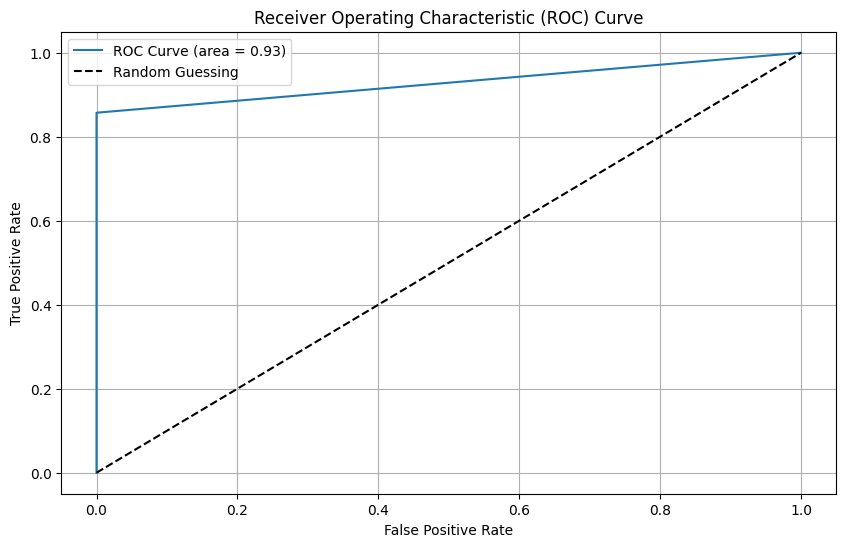

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid()
plt.show()